In [1]:
# ── Install (run once) ────────────────────────────────────────────────────────
# !pip install checkov pandas pyarrow datasets tqdm plotly kaleido --quiet

import os, json, subprocess, tempfile, textwrap, re
from pathlib import Path

import pandas as pd
import numpy as np
from tqdm.notebook import tqdm

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Column name constants (match parquet schema) ─────────────────────────────
_CODE_COL   = 'Reference output'
_PROMPT_COL = 'Prompt'
_DIFF_COL   = 'Difficulty'
_INTENT_COL = 'Intent'
_REGO_COL   = 'Rego intent'
_RES_COL    = 'Resource'

OUTPUT_DIR = Path('output/checkov_audit')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('✅ Imports OK')


✅ Imports OK


In [4]:
# from datasets import load_dataset
# ds  = load_dataset("autoiac-project/iac-eval", split="test")
# df  = ds.to_pandas()

PARQUET_GLOB = './iac_benchmark/iac_eval_hf/data/train.parquet'           # ← adjust path if needed
df = pd.read_parquet(PARQUET_GLOB)

# Normalise difficulty to int if stored as string ("Level 1" → 1)
if df[_DIFF_COL].dtype == object:
    df[_DIFF_COL] = df[_DIFF_COL].str.extract(r'(\d)').astype(int)

# Drop rows with no reference code
df = df.dropna(subset=[_CODE_COL]).reset_index(drop=True)

print(f'Loaded {len(df):,} scenarios  |  columns: {list(df.columns)}')
df.head(5)

Loaded 458 scenarios  |  columns: ['Resource', 'Prompt', 'Rego intent', 'Difficulty', 'Reference output', 'Intent']


,Resource,Prompt,Rego intent,Difficulty,Reference output,Intent
0,"aws_cloudwatch_log_group, aws_cloudwatch_log_r...",Configure a query log that can create a log st...,package terraform.validation\n\ndefault is_con...,5,terraform {\n required_providers {\n aws =...,"Has one ""aws_route53_zone"" resource\n with ..."
1,"aws_route53_vpc_association_authorization, aws...",Configure a valid Route 53 zone association re...,package terraform.validation\n\ndefault is_con...,3,"provider ""aws"" {\n region = ""us-east-1""\n}\...","Has multiple ""aws_vpc"" resource\n with a sp..."
2,"aws_elb, aws_route53_record, aws_route53_zone",Configure a Route 53 record with an Elastic Lo...,package terraform.validation\n\ndefault is_con...,3,"provider ""aws"" {\n region = ""us-east-1""\n}\n\...","Has one ""aws_route53_zone"" resource\n with ..."
3,"aws_db_instance, aws_db_instance, aws_db_insta...","Using route 53 resources, configure a weighted...",package terraform.validation\n\ndefault is_con...,6,terraform {\n required_providers {\n aws =...,"Has one ""aws_route53_zone"" resource\n with ..."
4,"aws_db_instance, aws_db_instance, aws_db_subne...",Configure Route 53 to return different databas...,package terraform.validation\n\ndefault is_con...,6,terraform {\n required_providers {\n aws =...,"Has one ""aws_vpc"" resource\n with a specifi..."


In [ ]:
# import subprocess, sys

# # Uninstall current broken install
# subprocess.run([sys.executable, '-m', 'pip', 'uninstall', 'checkov', '-y'], check=False)

# # Reinstall pinned to a known-good version for Python 3.12
# subprocess.run([
#     sys.executable, '-m', 'pip', 'install',
#     'checkov==3.2.350',          # last stable release before yaml-loader refactor
#     'pyyaml>=6.0.1',
#     'bc-python-hcl2>=0.3.51',
#     '--force-reinstall',
#     '--quiet',
# ], check=True)

# # Verify
# result = subprocess.run(['checkov', '--version'], capture_output=True, text=True)
# print('Checkov version:', result.stdout.strip())
# print('stderr:', result.stderr.strip())


In [6]:
# ── Diagnostic: inspect raw Checkov output for one template ──────────────────
sample_code = df[_CODE_COL].iloc[0]

with tempfile.TemporaryDirectory() as tmpdir:
    tf_path = Path(tmpdir) / 'main.tf'
    tf_path.write_text(str(sample_code), encoding='utf-8')

    proc = subprocess.run(
        ['checkov', '-f', str(tf_path), '--framework', 'terraform', '-o', 'json', '--quiet', '--compact'],
        capture_output=True, text=True, timeout=60
    )
    print('=== RETURN CODE ===')
    print(proc.returncode)
    print('=== STDOUT (first 3000 chars) ===')
    print(proc.stdout[:3000])
    print('=== STDERR (first 1000 chars) ===')
    print(proc.stderr[:1000])

=== RETURN CODE ===
1
=== STDOUT (first 3000 chars) ===
{
    "check_type": "terraform",
    "results": {
        "failed_checks": [
            {
                "check_id": "CKV_AWS_338",
                "bc_check_id": "BC_AWS_LOGGING_46",
                "check_name": "Ensure CloudWatch log groups retains logs for at least 1 year",
                "check_result": {
                    "result": "FAILED",
                    "evaluated_keys": []
                },
                "code_block": null,
                "file_path": "/main.tf",
                "file_abs_path": "/var/folders/mr/k47n2bks0fs1y0cmq922vqbh0000gn/T/tmptpfgex3m/main.tf",
                "repo_file_path": "/var/folders/mr/k47n2bks0fs1y0cmq922vqbh0000gn/T/tmptpfgex3m/main.tf",
                "file_line_range": [
                    26,
                    29
                ],
                "resource": "aws_cloudwatch_log_group.aws_route53_example_com",
                "evaluations": null,
                "chec

In [12]:
def run_checkov(tf_code: str, timeout: int = 60) -> dict:
    result = {
        'checkov_error':       None,
        'total_checks':        0,
        'passed_checks':       0,
        'failed_checks':       0,
        # PPR: passed/total, None when total_checks==0 (excluded from mean per IaCGen)
        'policy_pass_rate':    None,
        # FCR: True only if total_checks>0 AND failed==0  (IaCGen filtered definition)
        'filtered_compliance': False,
        # UCR eligibility: True for ALL templates regardless of check count
        # UCR is computed at the dataset level: (failed_checks==0).mean() over all rows
        'severity_high':       0,
        'severity_medium':     0,
        'severity_low':        0,
        'severity_info':       0,
        'violations':          [],
        'cis_violations':      [],
        'violation_ids':       [],
        'violation_names':     [],
        'checkov_log':         '',
    }

    with tempfile.TemporaryDirectory() as tmpdir:
        tf_path = Path(tmpdir) / 'main.tf'
        tf_path.write_text(str(tf_code), encoding='utf-8')

        cmd = [
            'checkov',
            '-f', str(tf_path),
            '--framework', 'terraform',
            '-o', 'json',
            '--quiet',
            '--compact',
            '--skip-download',        # avoids registry fetch that can emit extra text
        ]

        try:
            proc = subprocess.run(
                cmd, capture_output=True, text=True, timeout=timeout
            )
        except subprocess.TimeoutExpired:
            result['checkov_error'] = 'TimeoutExpired'
            return result
        except FileNotFoundError:
            result['checkov_error'] = 'checkov_not_found'
            return result
        except Exception as e:
            result['checkov_error'] = str(e)
            return result

        raw_stdout = proc.stdout
        raw_stderr = proc.stderr
        result['checkov_log'] = raw_stdout[:4000] + raw_stderr[:500]

        # ── Robust JSON extraction ────────────────────────────────────────
        # Checkov sometimes emits log lines / ANSI codes before the JSON blob.
        # Strategy: find the first '[' or '{' that starts a valid JSON structure.
        raw = None

        # Try 1: direct parse (clean output)
        try:
            raw = json.loads(raw_stdout)
        except json.JSONDecodeError:
            pass

        # Try 2: strip ANSI escape codes then parse
        if raw is None:
            clean = re.sub(r'\x1b\[[0-9;]*m', '', raw_stdout)
            try:
                raw = json.loads(clean)
            except json.JSONDecodeError:
                pass

        # Try 3: find first JSON array or object in the output (skip leading log lines)
        if raw is None:
            for start_char, end_char in [('[', ']'), ('{', '}')]:
                idx = raw_stdout.find(start_char)
                if idx != -1:
                    candidate = raw_stdout[idx:]
                    # trim to balanced close
                    depth, end_idx = 0, -1
                    for i, ch in enumerate(candidate):
                        if ch == start_char: depth += 1
                        elif ch == end_char:
                            depth -= 1
                            if depth == 0:
                                end_idx = i + 1
                                break
                    if end_idx != -1:
                        try:
                            raw = json.loads(candidate[:end_idx])
                            break
                        except json.JSONDecodeError:
                            pass

        if raw is None:
            result['checkov_error'] = 'json_parse_failed'
            result['checkov_log']   = raw_stdout[:2000] + '\nSTDERR: ' + raw_stderr[:500]
            return result

        # ── Normalise: Checkov v2 wraps in list, v3 may return dict directly ─
        if isinstance(raw, list):
            # filter to terraform results only
            tf_results = [r for r in raw if r.get('check_type') == 'terraform']
            raw = tf_results[0] if tf_results else (raw[0] if raw else {})

        # ── Summary counts ─────────────────────────────────────────────────
        summary = raw.get('summary', {})
        result['passed_checks'] = int(summary.get('passed',  0))
        result['failed_checks'] = int(summary.get('failed',  0))
        result['total_checks']  = result['passed_checks'] + result['failed_checks']

        if result['total_checks'] > 0:
            result['policy_pass_rate'] = round(
                result['passed_checks'] / result['total_checks'], 4
            )
        result['filtered_compliance'] = (
            result['total_checks'] > 0 and result['failed_checks'] == 0
        )
        
        result['checkov_passed'] = result['filtered_compliance']

        # ── Map failed checks ──────────────────────────────────────────────
        _SEV_MAP = {
            'HIGH': 'severity_high', 'MEDIUM': 'severity_medium',
            'LOW': 'severity_low',   'INFO': 'severity_info',
            'INFORMATIONAL': 'severity_info',
        }

        for chk in raw.get('results', {}).get('failed_checks', []):
            sev = (chk.get('severity') or 'NONE').upper()
            check_id   = chk.get('check_id',   '')
            check_name = chk.get('check_name', check_id)

            item = {
                'check_id':      check_id,
                'check_name':    check_name,
                'resource':      chk.get('resource', ''),
                'resource_type': chk.get('resource', '').split('.')[0],
                'severity':      sev,
                'guideline':     chk.get('guideline', ''),
                'file_line':     chk.get('file_line_range', []),
            }
            result['violations'].append(item)
            result['violation_ids'].append(check_id)
            result['violation_names'].append(check_name)
            result[_SEV_MAP.get(sev, 'severity_low')] += 1

            if re.match(r'CKV_AWS_', check_id):
                result['cis_violations'].append(check_id)

        return result


In [14]:
# ── Batch scan ────────────────────────────────────────────────────────────────
checkov_results = []

for code in tqdm(df[_CODE_COL], desc='Checkov scan', unit='template'):
    checkov_results.append(run_checkov(str(code)))

# ── Expand flat scalar columns into the main dataframe ───────────────────────
SCALAR_COLS = [
    'checkov_passed', 'checkov_error',
    'total_checks', 'passed_checks', 'failed_checks',
    'policy_pass_rate', 'filtered_compliance',
    'severity_high', 'severity_medium', 'severity_low', 'severity_info',
    'checkov_log',
]

df_chk = pd.DataFrame(checkov_results)
for col in SCALAR_COLS:
    df[col] = df_chk[col]

# Keep list columns separate (not great in a flat DataFrame)
df['violation_ids']   = df_chk['violation_ids']
df['violation_names'] = df_chk['violation_names']
df['violations_json'] = df_chk['violations'].apply(json.dumps)  # serialisable
df['cis_violations']  = df_chk['cis_violations']

# ── Severity-weighted violation score (HIGH=3, MED=2, LOW=1, INFO=0.5) ────────
df['swvs'] = (
    df['severity_high']   * 3 +
    df['severity_medium'] * 2 +
    df['severity_low']    * 1 +
    df['severity_info']   * 0.5
)

print(f"\nCheckov scan complete")
print(f"  Templates scanned          : {len(df):,}")
print(f"  Fully compliant (FCR)      : {df['filtered_compliance'].sum():,}  "
      f"({df['filtered_compliance'].mean()*100:.1f}%)")
print(f"  Mean policy pass rate (PPR): {df['policy_pass_rate'].mean()*100:.1f}%")
print(f"  Total violations found     : {df['failed_checks'].sum():,}")


Checkov scan:   0%|          | 0/458 [00:00<?, ?template/s]


Checkov scan complete
  Templates scanned          : 458
  Fully compliant (FCR)      : 59  (12.9%)
  Mean policy pass rate (PPR): 57.6%
  Total violations found     : 3,316


In [16]:
# Save full results (list columns serialised as JSON strings)
SAVE_COLS = list(df.columns)
save_df = df.copy()
# list-type cols → JSON string for CSV compatibility
for lc in ['violation_ids', 'violation_names', 'cis_violations']:
    save_df[lc] = save_df[lc].apply(json.dumps)

save_df[SAVE_COLS].to_csv(OUTPUT_DIR / 'iac_eval_checkov_results.csv', index=False)
save_df[SAVE_COLS].to_parquet(OUTPUT_DIR / 'iac_eval_checkov_results.parquet', index=False)
print(f'Saved enriched dataset → {OUTPUT_DIR}')
print(save_df.columns)
save_df[['Prompt','Reference output','checkov_passed', 'checkov_error', 'total_checks',
       'passed_checks', 'failed_checks', 'policy_pass_rate',
       'filtered_compliance', 'severity_high', 'severity_medium',
       'severity_low', 'severity_info', 'checkov_log', 'violation_ids',
       'violation_names', 'violations_json', 'cis_violations', 'swvs']].head()

Saved enriched dataset → output/checkov_audit
Index(['Resource', 'Prompt', 'Rego intent', 'Difficulty', 'Reference output',
       'Intent', 'checkov_passed', 'checkov_error', 'total_checks',
       'passed_checks', 'failed_checks', 'policy_pass_rate',
       'filtered_compliance', 'severity_high', 'severity_medium',
       'severity_low', 'severity_info', 'checkov_log', 'violation_ids',
       'violation_names', 'violations_json', 'cis_violations', 'swvs'],
      dtype='object')


,Prompt,Reference output,checkov_passed,checkov_error,total_checks,passed_checks,failed_checks,policy_pass_rate,filtered_compliance,severity_high,severity_medium,severity_low,severity_info,checkov_log,violation_ids,violation_names,violations_json,cis_violations,swvs
0,Configure a query log that can create a log st...,terraform {\n required_providers {\n aws =...,False,None,17,14,3,0.8235,False,0,0,3,0,"{\n ""check_type"": ""terraform"",\n ""result...","[""CKV_AWS_338"", ""CKV_AWS_158"", ""CKV2_AWS_38""]","[""Ensure CloudWatch log groups retains logs fo...","[{""check_id"": ""CKV_AWS_338"", ""check_name"": ""En...","[""CKV_AWS_338"", ""CKV_AWS_158""]",3.0
1,Configure a valid Route 53 zone association re...,"provider ""aws"" {\n region = ""us-east-1""\n}\...",False,None,7,1,6,0.1429,False,0,0,6,0,"{\n ""check_type"": ""terraform"",\n ""result...","[""CKV2_AWS_12"", ""CKV2_AWS_12"", ""CKV2_AWS_39"", ...","[""Ensure the default security group of every V...","[{""check_id"": ""CKV2_AWS_12"", ""check_name"": ""En...",[],6.0
2,Configure a Route 53 record with an Elastic Lo...,"provider ""aws"" {\n region = ""us-east-1""\n}\n\...",False,None,9,4,5,0.4444,False,0,0,5,0,"{\n ""check_type"": ""terraform"",\n ""result...","[""CKV_AWS_127"", ""CKV_AWS_92"", ""CKV_AWS_376"", ""...","[""Ensure that Elastic Load Balancer(s) uses SS...","[{""check_id"": ""CKV_AWS_127"", ""check_name"": ""En...","[""CKV_AWS_127"", ""CKV_AWS_92"", ""CKV_AWS_376""]",5.0
3,"Using route 53 resources, configure a weighted...",terraform {\n required_providers {\n aws =...,False,None,60,20,40,0.3333,False,0,0,40,0,"{\n ""check_type"": ""terraform"",\n ""result...","[""CKV_AWS_161"", ""CKV_AWS_354"", ""CKV_AWS_293"", ...","[""Ensure RDS database has IAM authentication e...","[{""check_id"": ""CKV_AWS_161"", ""check_name"": ""En...","[""CKV_AWS_161"", ""CKV_AWS_354"", ""CKV_AWS_293"", ...",40.0
4,Configure Route 53 to return different databas...,terraform {\n required_providers {\n aws =...,False,None,35,10,25,0.2857,False,0,0,25,0,"{\n ""check_type"": ""terraform"",\n ""result...","[""CKV_AWS_161"", ""CKV_AWS_354"", ""CKV_AWS_293"", ...","[""Ensure RDS database has IAM authentication e...","[{""check_id"": ""CKV_AWS_161"", ""check_name"": ""En...","[""CKV_AWS_161"", ""CKV_AWS_354"", ""CKV_AWS_293"", ...",25.0


In [20]:
# ── Explode violation_ids to get per-check counts ─────────────────────────────
all_violations = (
    df[['violation_ids', 'violation_names', _DIFF_COL, _RES_COL]]
    .explode('violation_ids')
    .rename(columns={'violation_ids': 'check_id'})
    .dropna(subset=['check_id'])
    .query("check_id != ''")
)

# Attach human-readable names
name_pairs = []
for _, row in df.iterrows():
    ids   = row['violation_ids']   if isinstance(row['violation_ids'],   list) else []
    names = row['violation_names'] if isinstance(row['violation_names'], list) else []
    name_pairs.extend(zip(ids, names))

name_map = dict(name_pairs)  # last-write-wins for duplicates, which is fine

all_violations['check_name'] = all_violations['check_id'].map(name_map)

# ── Top violations overall ────────────────────────────────────────────────────
top_violations = (
    all_violations.groupby(['check_id', 'check_name'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
    .head(20)
)

# ── Violations by difficulty ───────────────────────────────────────────────────
vuln_by_diff = (
    all_violations.groupby([_DIFF_COL, 'check_id'])
    .size()
    .reset_index(name='count')
)

# ── Summary table by difficulty ────────────────────────────────────────────────
# policy_pass_rate is None for templates with 0 applicable checks → cast to float first
df['policy_pass_rate'] = pd.to_numeric(df['policy_pass_rate'], errors='coerce')

summary_table = (
    df.groupby(_DIFF_COL)
    .agg(
        scenarios          = (_CODE_COL,            'count'),
        # UCR: failed==0 over ALL rows in this difficulty group
        ucr                = ('failed_checks',       lambda x: (x == 0).mean()),
        # FCR: failed==0 only over rows where total_checks > 0
        fcr                = ('filtered_compliance', 'mean'),
        # PPR: mean of policy_pass_rate, NaN rows auto-excluded by pandas mean()
        mean_ppr           = ('policy_pass_rate',    'mean'),
        mean_violations    = ('failed_checks',       'mean'),
        mean_swvs          = ('swvs',                'mean'),
        total_high         = ('severity_high',       'sum'),
        total_medium       = ('severity_medium',     'sum'),
        total_low          = ('severity_low',        'sum'),
    )
    .reset_index()
)

summary_table['ucr']      = (summary_table['ucr']      * 100).round(1)
summary_table['fcr']      = (summary_table['fcr']      * 100).round(1)
summary_table['mean_ppr'] = (summary_table['mean_ppr'] * 100).round(1)  # no fillna(0)!

print(summary_table.to_string(index=False))

 Difficulty  scenarios  ucr  fcr  mean_ppr  mean_violations  mean_swvs  total_high  total_medium  total_low
          1         45 53.3 15.6      45.4         2.688889   2.688889           0             0        121
          2         95 30.5 14.7      48.1         4.178947   4.178947           0             0        397
          3        113 31.0 23.0      60.9         3.318584   3.318584           0             0        375
          4         58 12.1 12.1      64.2         7.017241   7.017241           0             0        407
          5         72  1.4  1.4      62.6        11.402778  11.402778           0             0        821
          6         75  5.3  5.3      58.0        15.933333  15.933333           0             0       1195


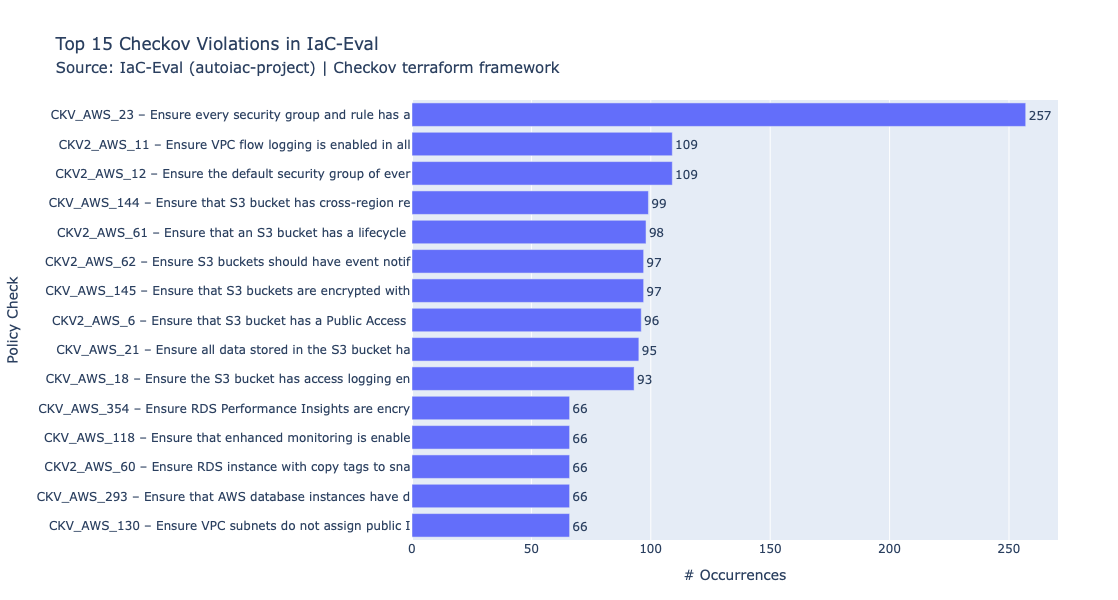

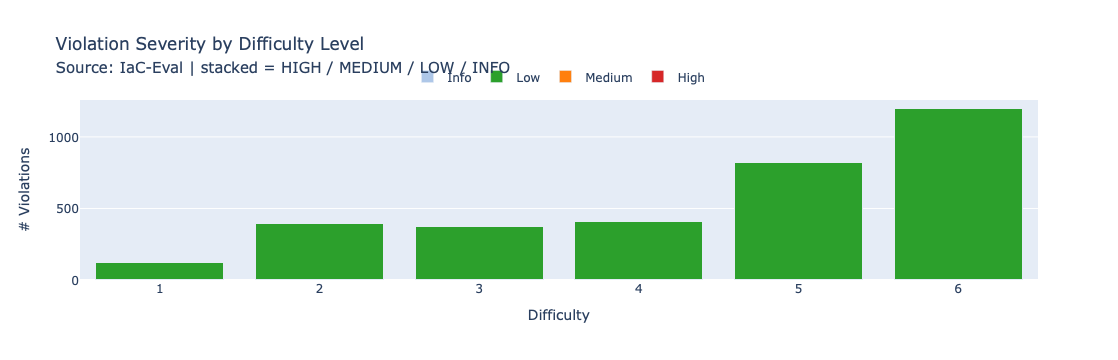

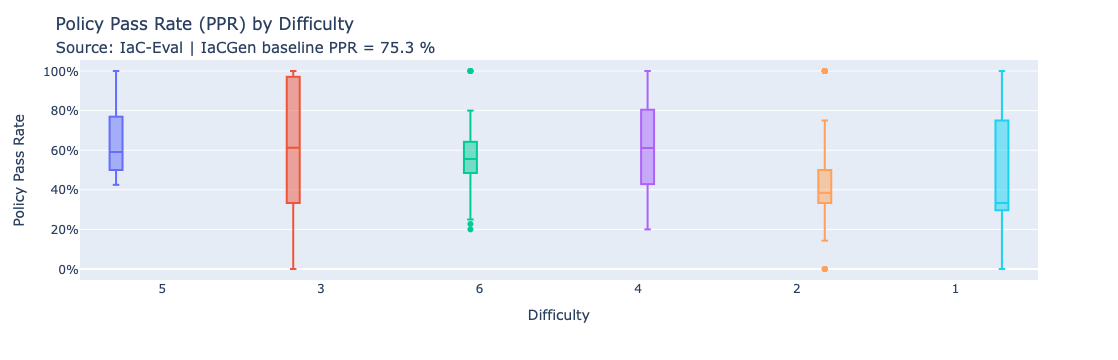

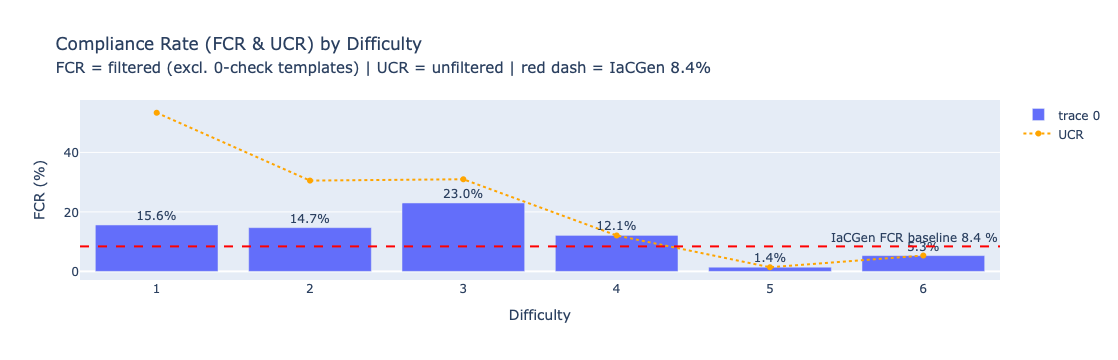

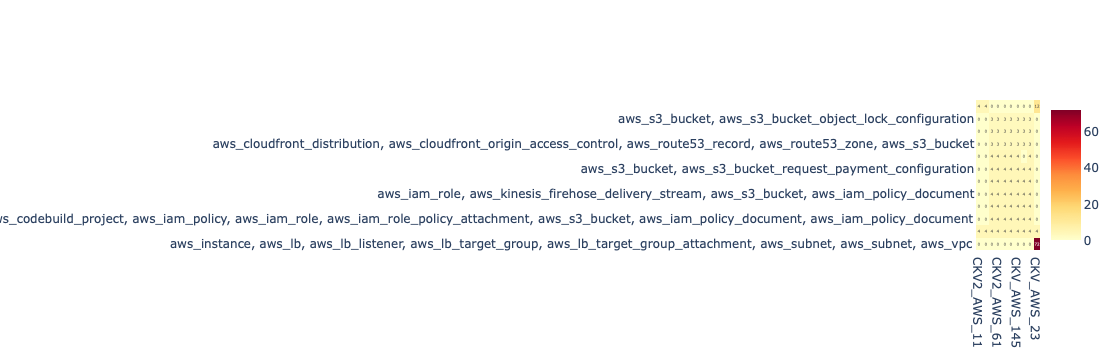

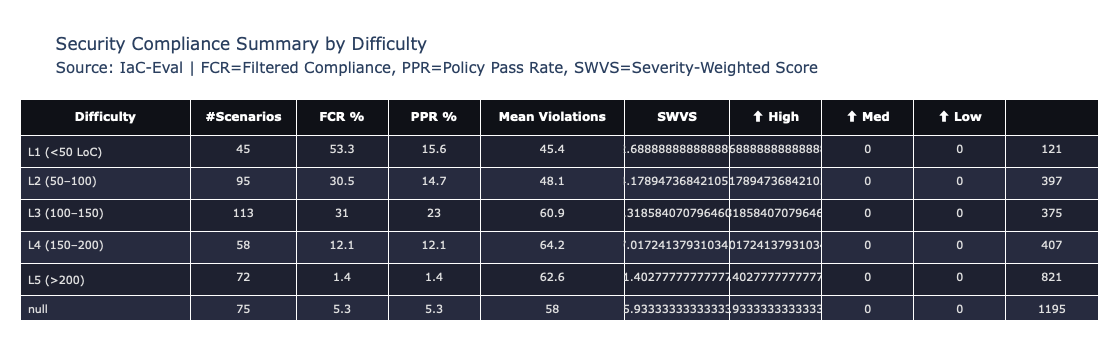

All 6 figures saved → output/checkov_audit


In [24]:
import json as _json

# ── 1. Top 15 Vulnerabilities (horizontal bar) ────────────────────────────────
top15 = top_violations.head(15).sort_values('count')
label = top15['check_id'] + ' – ' + top15['check_name'].fillna('')
label = label.str[:55]   # truncate long names

fig1 = go.Figure(go.Bar(
    x=top15['count'], y=label, orientation='h',
    text=top15['count'], textposition='outside',
))
fig1.update_layout(
    title=dict(text=(
        'Top 15 Checkov Violations in IaC-Eval<br>'
        "<span style='font-size:15px;font-weight:normal;'>"
        "Source: IaC-Eval (autoiac-project) | Checkov terraform framework"
        "</span>"
    )),
    xaxis_title='# Occurrences',
    yaxis_title='Policy Check',
    margin=dict(l=380, r=60, t=100, b=60),
    height=600,
)
fig1.update_traces(cliponaxis=False)
fig1.show()
fig1.write_image(str(OUTPUT_DIR / 'top15_violations.png'))
with open(str(OUTPUT_DIR / 'top15_violations.png.meta.json'), 'w') as f:
    _json.dump({'caption': 'Top 15 Checkov policy violations across IaC-Eval templates',
                'description': 'Horizontal bar chart counting each failed Checkov check'}, f)

# ── 2. Severity breakdown (stacked bar by difficulty) ─────────────────────────
sev_cols   = ['severity_high', 'severity_medium', 'severity_low', 'severity_info']
sev_labels = ['High', 'Medium', 'Low', 'Info']
sev_colors = ['#d62728', '#ff7f0e', '#2ca02c', '#aec7e8']

sev_by_diff = df.groupby(_DIFF_COL)[sev_cols].sum().reset_index()

fig2 = go.Figure()
for col, label2, color in zip(sev_cols, sev_labels, sev_colors):
    fig2.add_bar(
        x=sev_by_diff[_DIFF_COL].astype(str),
        y=sev_by_diff[col],
        name=label2,
        marker_color=color,
    )
fig2.update_layout(
    barmode='stack',
    title=dict(text=(
        'Violation Severity by Difficulty Level<br>'
        "<span style='font-size:15px;font-weight:normal;'>"
        "Source: IaC-Eval | stacked = HIGH / MEDIUM / LOW / INFO"
        "</span>"
    )),
    xaxis_title='Difficulty',
    yaxis_title='# Violations',
    legend=dict(orientation='h', yanchor='bottom', y=1.05, xanchor='center', x=0.5),
)
fig2.show()
fig2.write_image(str(OUTPUT_DIR / 'severity_by_difficulty.png'))
with open(str(OUTPUT_DIR / 'severity_by_difficulty.png.meta.json'), 'w') as f:
    _json.dump({'caption': 'Violation severity distribution by DPIaC-Eval difficulty',
                'description': 'Stacked bar chart with HIGH/MEDIUM/LOW/INFO per difficulty level'}, f)

# ── 3. Policy Pass Rate distribution (box plot by difficulty) ─────────────────
fig3 = px.box(
    df.dropna(subset=['policy_pass_rate']),
    x=df.dropna(subset=['policy_pass_rate'])[_DIFF_COL].astype(str),
    y='policy_pass_rate',
    color=df.dropna(subset=['policy_pass_rate'])[_DIFF_COL].astype(str),
    points='outliers',
    category_orders={_DIFF_COL: [str(i) for i in range(1, 6)]},
)
fig3.update_layout(
    title=dict(text=(
        'Policy Pass Rate (PPR) by Difficulty<br>'
        "<span style='font-size:15px;font-weight:normal;'>"
        "Source: IaC-Eval | IaCGen baseline PPR = 75.3 %"
        "</span>"
    )),
    xaxis_title='Difficulty',
    yaxis_title='Policy Pass Rate',
    showlegend=False,
)
fig3.update_yaxes(tickformat='.0%')
fig3.show()
fig3.write_image(str(OUTPUT_DIR / 'ppr_by_difficulty.png'))
with open(str(OUTPUT_DIR / 'ppr_by_difficulty.png.meta.json'), 'w') as f:
    _json.dump({'caption': 'Policy pass rate spread per difficulty level',
                'description': 'Box plot of PPR showing IQR + outliers by difficulty'}, f)

# ── 4. Filtered Compliance Rate (FCR) per difficulty (bar) ────────────────────
fcr = (
    df.groupby(_DIFF_COL)['filtered_compliance']
    .mean()
    .reset_index()
    .rename(columns={'filtered_compliance': 'fcr'})
)
fcr['fcr_pct'] = (fcr['fcr'] * 100).round(1)

ucr_by_diff = (
    df.groupby(_DIFF_COL)['failed_checks']
    .apply(lambda x: (x == 0).mean() * 100)
    .reset_index(name='ucr_pct')
)

fig4 = go.Figure(go.Bar(
    x=fcr[_DIFF_COL].astype(str),
    y=fcr['fcr_pct'],
    text=fcr['fcr_pct'].astype(str) + '%',
    textposition='outside',
))
fig4.add_hline(
    y=8.4, line_dash='dash', line_color='red',
    annotation_text='IaCGen FCR baseline 8.4 %',
    annotation_position='top right',
)
fig4.update_layout(
    title=dict(text=(
        'Filtered Compliance Rate (FCR) by Difficulty<br>'
        "<span style='font-size:15px;font-weight:normal;'>"
        "Source: IaC-Eval | red dash = IaCGen 8.4 % baseline"
        "</span>"
    )),
    xaxis_title='Difficulty',
    yaxis_title='FCR (%)',
)
fig4.add_trace(go.Scatter(
    x=ucr_by_diff[_DIFF_COL].astype(str),
    y=ucr_by_diff['ucr_pct'],
    mode='lines+markers',
    name='UCR',
    line=dict(color='orange', dash='dot'),
))
# Update title to reflect both metrics
fig4.update_layout(
    title="Compliance Rate (FCR & UCR) by Difficulty<br>"
          "<span style='font-size:15px;font-weight:normal;'>"
          "FCR = filtered (excl. 0-check templates) | UCR = unfiltered | red dash = IaCGen 8.4%"
          "</span>"
)
fig4.update_traces(cliponaxis=False)
fig4.show()
fig4.write_image(str(OUTPUT_DIR / 'fcr_by_difficulty.png'))
with open(str(OUTPUT_DIR / 'fcr_by_difficulty.png.meta.json'), 'w') as f:
    _json.dump({'caption': 'Filtered compliance rate per difficulty vs IaCGen baseline',
                'description': 'Bar chart of FCR% by difficulty with IaCGen 8.4% reference line'}, f)

# ── 5. Top 10 violated check IDs by Resource type (heat map) ──────────────────
top10_ids = top_violations['check_id'].head(10).tolist()
heat_df   = all_violations[all_violations['check_id'].isin(top10_ids)]
heat_piv  = (
    heat_df.groupby([_RES_COL, 'check_id'])
    .size()
    .unstack(fill_value=0)
)
# Keep top 12 resource types by total violations
heat_piv = heat_piv.loc[heat_piv.sum(axis=1).nlargest(12).index]

fig5 = go.Figure(go.Heatmap(
    z=heat_piv.values,
    x=heat_piv.columns.tolist(),
    y=heat_piv.index.tolist(),
    colorscale='YlOrRd',
    text=heat_piv.values,
    texttemplate='%{text}',
))
fig5.show()
fig5.update_layout(
    title=dict(text=(
        'Violation Heatmap: Resource × Check ID<br>'
        "<span style='font-size:15px;font-weight:normal;'>"
        "Source: IaC-Eval | top-12 resource types, top-10 check IDs"
        "</span>"
    )),
    xaxis_title='Check ID',
    yaxis_title='Resource Type',
    margin=dict(l=200, r=40, t=100, b=120),
    height=600,
)
fig5.write_image(str(OUTPUT_DIR / 'violation_heatmap.png'))
with open(str(OUTPUT_DIR / 'violation_heatmap.png.meta.json'), 'w') as f:
    _json.dump({'caption': 'Heatmap of top-10 Checkov violations per AWS resource type',
                'description': 'Cell values = raw violation count; rows = resource, cols = check ID'}, f)

# ── 6. Compliance summary styled table ────────────────────────────────────────
tbl = summary_table.copy()
tbl[_DIFF_COL] = tbl[_DIFF_COL].map({
    1: 'L1 (<50 LoC)', 2: 'L2 (50–100)',
    3: 'L3 (100–150)', 4: 'L4 (150–200)', 5: 'L5 (>200)'
})

n = len(tbl)
fills = [['#1e2130' if i % 2 == 0 else '#272b3f' for i in range(n)]] * len(tbl.columns)
hdrs  = ['Difficulty', '#Scenarios', 'FCR %', 'PPR %',
         'Mean Violations', 'SWVS', '⬆ High', '⬆ Med', '⬆ Low']

fig6 = go.Figure(go.Table(
    columnwidth=[130, 80, 70, 70, 110, 80, 70, 70, 70],
    header=dict(
        values    =[f'<b>{h}</b>' for h in hdrs],
        fill_color='#0f1117', font=dict(color='white', size=12),
        align='center', height=36,
    ),
    cells=dict(
        values    =[tbl[c].tolist() for c in tbl.columns],
        fill_color=fills,
        font=dict(color='#e0e0e0', size=11),
        align=['left'] + ['center'] * (len(hdrs) - 1),
        height=32,
    ),
))
fig6.update_layout(
    title=dict(text=(
        'Security Compliance Summary by Difficulty<br>'
        "<span style='font-size:15px;font-weight:normal;'>"
        "Source: IaC-Eval | FCR=Filtered Compliance, PPR=Policy Pass Rate, SWVS=Severity-Weighted Score"
        "</span>"
    )),
    margin=dict(l=20, r=20, t=100, b=20), height=340,
)
fig6.show()
fig6.write_image(str(OUTPUT_DIR / 'compliance_summary_table.png'))
with open(str(OUTPUT_DIR / 'compliance_summary_table.png.meta.json'), 'w') as f:
    _json.dump({'caption': 'Checkov security compliance summary per difficulty level',
                'description': 'Table with FCR, PPR, mean violations, SWVS, and severity counts'}, f)

print('All 6 figures saved →', OUTPUT_DIR)


In [26]:
# ── IaCGen-aligned metric definitions ─────────────────────────────────────
# PPR  = mean(passed/total) over templates where total_checks > 0   (NaN excluded)
# FCR  = mean(failed==0)    over templates where total_checks > 0   (filtered)
# UCR  = mean(failed==0)    over ALL templates incl. total_checks==0 (unfiltered)

total   = len(df)
n_with_checks = (df['total_checks'] > 0).sum()

ucr = (df['failed_checks'] == 0).mean()                          # unfiltered: all 458
fcr = df.loc[df['total_checks'] > 0, 'failed_checks'].eq(0).mean()  # filtered: only those with checks
ppr = df.loc[df['total_checks'] > 0, 'policy_pass_rate'].mean()     # NaN-safe, same denominator as FCR

print(f"\nCheckov scan complete")
print(f"  Templates scanned                    : {total:,}")
print(f"  Templates with applicable checks     : {n_with_checks:,}  ({n_with_checks/total*100:.1f}%)")
print(f"  Unfiltered Compliance Rate  (UCR)    : {ucr*100:.1f}%   ← denominator: all {total}")
print(f"  Filtered   Compliance Rate  (FCR)    : {fcr*100:.1f}%   ← denominator: {n_with_checks} with checks")
print(f"  Mean Policy Pass Rate       (PPR)    : {ppr*100:.1f}%   ← denominator: {n_with_checks} with checks")
print(f"  Total violations found               : {df['failed_checks'].sum():,}")


Checkov scan complete
  Templates scanned                    : 458
  Templates with applicable checks     : 417  (91.0%)
  Unfiltered Compliance Rate  (UCR)    : 21.8%   ← denominator: all 458
  Filtered   Compliance Rate  (FCR)    : 14.1%   ← denominator: 417 with checks
  Mean Policy Pass Rate       (PPR)    : 57.6%   ← denominator: 417 with checks
  Total violations found               : 3,316


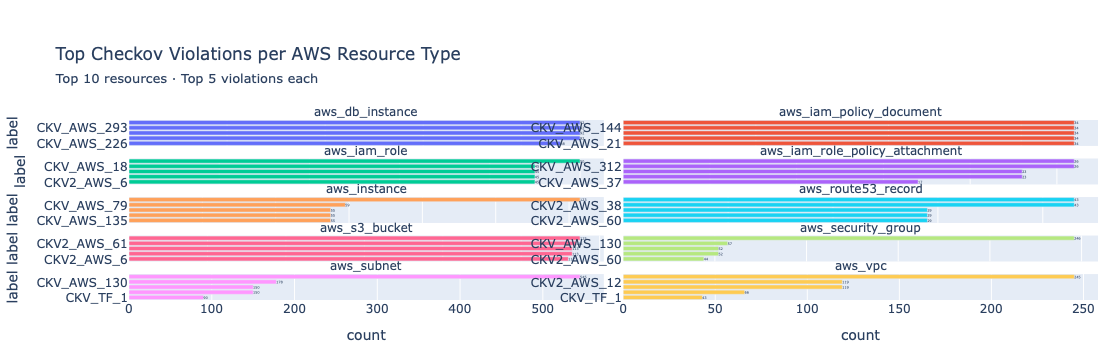


Top 10 resources by total violations:
resource
aws_subnet                        3353
aws_vpc                           1711
aws_security_group                1412
aws_s3_bucket                     1250
aws_iam_role                      1185
aws_db_instance                   1127
aws_instance                       768
aws_iam_policy_document            648
aws_route53_record                 637
aws_iam_role_policy_attachment     495


In [28]:
# ── Top violations per resource type ──────────────────────────────────────────
import ast

# 1. Explode violation_ids and violation_names in parallel
#    Both lists are aligned (same index = same check), so we zip them.
df_exploded = df[[_RES_COL, 'violation_ids', 'violation_names']].copy()

# Build a long-form dataframe: one row per (scenario, violation)
rows = []
for _, row in df_exploded.iterrows():
    ids   = row['violation_ids']   if isinstance(row['violation_ids'],   list) else []
    names = row['violation_names'] if isinstance(row['violation_names'], list) else []
    # Handle JSON-string form if loaded from saved CSV
    if isinstance(ids,   str): ids   = json.loads(ids)
    if isinstance(names, str): names = json.loads(names)
    for cid, cname in zip(ids, names):
        if cid:  # skip empty
            rows.append({'resource': row[_RES_COL], 'check_id': cid, 'check_name': cname})

df_long = pd.DataFrame(rows)

# 2. Explode multi-resource rows (Resource col is comma-separated like
#    "aws_s3_bucket, aws_iam_role") → one resource type per row
df_long['resource'] = df_long['resource'].str.split(',')
df_long = df_long.explode('resource')
df_long['resource'] = df_long['resource'].str.strip()

# 3. Count occurrences per (resource_type, check_id)
violation_counts = (
    df_long.groupby(['resource', 'check_id', 'check_name'])
    .size()
    .reset_index(name='count')
)

# 4. Keep top-N violations per resource (by count), then top-K resources overall
TOP_VIOLATIONS_PER_RESOURCE = 5
TOP_RESOURCES = 10

top_per_resource = (
    violation_counts
    .sort_values('count', ascending=False)
    .groupby('resource')
    .head(TOP_VIOLATIONS_PER_RESOURCE)
)

# Rank resources by their total violation count, keep top-K
resource_totals = (
    violation_counts.groupby('resource')['count']
    .sum()
    .sort_values(ascending=False)
)
top_resources = resource_totals.head(TOP_RESOURCES).index.tolist()

plot_df = (
    top_per_resource[top_per_resource['resource'].isin(top_resources)]
    .copy()
)

# Short label: "CKV_AWS_338" rather than the full description for readability
plot_df['label'] = plot_df['check_id']

# 5. Plot: faceted horizontal bar — one subplot per resource type
fig = px.bar(
    plot_df.sort_values(['resource', 'count'], ascending=[True, True]),
    x='count',
    y='label',
    color='resource',
    facet_col='resource',
    facet_col_wrap=2,
    orientation='h',
    text='count',
    hover_data={'check_name': True, 'check_id': True, 'count': True, 'resource': False},
    title='Top Checkov Violations per AWS Resource Type<br>'
          '<span style="font-size:13px;font-weight:normal">'
          f'Top {TOP_RESOURCES} resources · Top {TOP_VIOLATIONS_PER_RESOURCE} violations each'
          '</span>',
    color_discrete_sequence=px.colors.qualitative.Plotly,
)

fig.update_traces(textposition='outside', cliponaxis=False)
fig.update_layout(
    height=300 * ((len(top_resources) + 1) // 2),
    showlegend=False,
    margin=dict(t=120, l=20, r=20, b=60),
)
# Remove redundant "resource=" prefix from facet titles
fig.for_each_annotation(lambda a: a.update(text=a.text.split('=')[-1]))
# Each facet has independent y-axis so bars don't crowd
fig.update_yaxes(matches=None, showticklabels=True)
fig.update_xaxes(matches=None)

fig.write_image(OUTPUT_DIR / 'top_violations_per_resource.png', scale=2)
fig.show()

print(f"\nTop {TOP_RESOURCES} resources by total violations:")
print(resource_totals.head(TOP_RESOURCES).to_string())


# Trivy

In [30]:
# ── Trivy diagnostic: inspect raw output for sample[0] ───────────────────────
import shutil, tempfile

sample_code = df[_CODE_COL].iloc[0]
_tmpdir = tempfile.mkdtemp()
try:
    _tf = Path(_tmpdir) / 'main.tf'
    _tf.write_text(str(sample_code), encoding='utf-8')

    _proc = subprocess.run(
        ['trivy', 'config', '--format', 'json', str(_tmpdir)],
        capture_output=True, text=True, timeout=90
    )
    print('=== VERSION ===')
    subprocess.run(['trivy', '--version'], capture_output=False)
    print('\n=== RETURN CODE ===', _proc.returncode)
    print('=== STDOUT ===')
    # print(_proc.stdout[:3000])
    print(_proc.stdout)
    print('=== STDERR ===')
    print(_proc.stderr[:500])
finally:
    shutil.rmtree(_tmpdir, ignore_errors=True)

=== VERSION ===
Version: 0.69.3
Check Bundle:
  Digest: sha256:1583562f8b90ed2a071b99f0e5ffff6b57e4ceb6ca3e4796577b4e6a339eb74c
  DownloadedAt: 2026-03-21 06:22:20.731658 +0000 UTC

=== RETURN CODE === 0
=== STDOUT ===
{
  "SchemaVersion": 2,
  "Trivy": {
    "Version": "0.69.3"
  },
  "ReportID": "019d0f72-611c-7298-80ad-0959f4d1a9c9",
  "CreatedAt": "2026-03-21T19:10:47.452172+11:00",
  "ArtifactName": "/var/folders/mr/k47n2bks0fs1y0cmq922vqbh0000gn/T/tmp84z_9n3a",
  "ArtifactType": "filesystem",
  "Results": [
    {
      "Target": ".",
      "Class": "config",
      "Type": "terraform",
      "MisconfSummary": {
        "Successes": 51,
        "Failures": 0
      }
    },
    {
      "Target": "main.tf",
      "Class": "config",
      "Type": "terraform",
      "MisconfSummary": {
        "Successes": 0,
        "Failures": 1
      },
      "Misconfigurations": [
        {
          "Type": "Terraform Security Check",
          "ID": "AWS-0017",
          "Title": "CloudWatch log 

In [124]:
import requests, re

_TRIVY_CHECKS_API = (
    "https://api.github.com/repos/aquasecurity/trivy-checks/"
    "git/trees/HEAD?recursive=1"
)

def _build_avd_title_map() -> dict[str, str]:
    """
    Parse # METADATA OPA annotations from .rego files in trivy-checks.
    Extracts:  # title: ...  and  #   id: AWS-XXXX  (under custom:)
    Returns dict with both short ID (AWS-0086) and alias (AVD-AWS-0086) → title.
    """
    title_map: dict[str, str] = {}

    resp = requests.get(_TRIVY_CHECKS_API, timeout=30)
    resp.raise_for_status()
    tree = resp.json().get('tree', [])

    # Only main check files — skip _test.rego
    rego_paths = [
        item['path'] for item in tree
        if item['path'].startswith('checks/cloud/aws/')
        and item['path'].endswith('.rego')
        and not item['path'].endswith('_test.rego')
        and 'lib/' not in item['path']
    ]

    print(f"  Found {len(rego_paths)} AWS check .rego files — downloading...")

    raw_base = "https://raw.githubusercontent.com/aquasecurity/trivy-checks/HEAD/"

    for path in rego_paths:
        try:
            r = requests.get(raw_base + path, timeout=15)
            r.raise_for_status()
            content = r.text
        except Exception:
            continue

        # Extract: # title: S3 Access block should block public ACL
        title_match = re.search(r'^# title:\s*(.+)$', content, re.MULTILINE)
        # Extract: #   id: AWS-0086  (indented under custom:)
        id_match    = re.search(r'^#\s+id:\s*(AWS-\d+)\s*$', content, re.MULTILINE)

        if not title_match or not id_match:
            continue

        title    = title_match.group(1).strip()
        short_id = id_match.group(1).strip()            # AWS-0086
        avd_id   = f"AVD-{short_id}"                   # AVD-AWS-0086

        title_map[short_id] = title
        title_map[avd_id]   = title

    return title_map


AVD_TITLE_MAP = _build_avd_title_map()
print(f"  Registry built: {len(AVD_TITLE_MAP)} ID → title entries")
print(f"  Example: AWS-0086 → {AVD_TITLE_MAP.get('AWS-0086', 'NOT FOUND')}")
print(f"  Example: AWS-0089 → {AVD_TITLE_MAP.get('AWS-0089', 'NOT FOUND')}")
print(f"  Example: AWS-0087 → {AVD_TITLE_MAP.get('AWS-0087', 'NOT FOUND')}")


  Found 175 AWS check .rego files — downloading...
  Registry built: 350 ID → title entries
  Example: AWS-0086 → S3 Access block should block public ACL
  Example: AWS-0089 → S3 Bucket Logging
  Example: AWS-0087 → S3 Access block should block public policy


In [126]:
# ── Trivy scan helper ─────────────────────────────────────────────────────────
# Requires: trivy installed and in PATH  (brew install aquasecurity/trivy/trivy)
# Uses the `config` scanner (misconfig / IaC checks) on a temp .tf file.

TRIVY_OUTPUT_DIR = Path('output/trivy_audit')
TRIVY_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

_TRIVY_SEV_MAP = {
    'CRITICAL': 'severity_critical',
    'HIGH':     'severity_high',
    'MEDIUM':   'severity_medium',
    'LOW':      'severity_low',
    'UNKNOWN':  'severity_unknown',
}

def run_trivy(tf_code: str, timeout: int = 90) -> dict:
    result = {
        'trivy_passed':       False,
        'trivy_error':        None,
        'total_checks':       0,
        'passed_checks':      0,
        'failed_checks':      0,
        'policy_pass_rate':   None,
        'filtered_compliance': False,
        'severity_critical':  0,
        'severity_high':      0,
        'severity_medium':    0,
        'severity_low':       0,
        'severity_unknown':   0,
        'violations':         [],
        'violation_ids':      [],
        'violation_titles':   [],
        'trivy_log':          '',
    }

    import shutil
    tmpdir = tempfile.mkdtemp()
    try:
        tf_path = Path(tmpdir) / 'main.tf'
        tf_path.write_text(str(tf_code), encoding='utf-8')

        cmd = [
            'trivy', 'config',
            '--format', 'json',
            '--quiet',
            '--include-non-failures',
            '--tf-exclude-downloaded-modules',  # avoids scanning .terraform/ subdirs
            str(tmpdir),
        ]

        try:
            proc = subprocess.run(
                cmd, capture_output=True, text=True, timeout=timeout
            )
        except subprocess.TimeoutExpired:
            result['trivy_error'] = 'TimeoutExpired'
            return result
        except FileNotFoundError:
            result['trivy_error'] = 'trivy_not_found'
            return result
        except Exception as e:
            result['trivy_error'] = str(e)
            return result

        raw_stdout = proc.stdout
        raw_stderr = proc.stderr
        result['trivy_log'] = raw_stdout[:4000] + raw_stderr[:500]

        # ── Robust JSON extraction ────────────────────────────────────────────
        raw = None
        try:
            raw = json.loads(raw_stdout)
        except json.JSONDecodeError:
            pass

        if raw is None:
            clean = re.sub(r'\x1b\[[0-9;]*m', '', raw_stdout)
            try:
                raw = json.loads(clean)
            except json.JSONDecodeError:
                pass

        if raw is None:
            result['trivy_error'] = 'json_parse_failed'
            result['trivy_log']   = raw_stdout[:2000] + '\nSTDERR: ' + raw_stderr[:500]
            return result

        # ── Parse Trivy JSON schema ───────────────────────────────────────────
        # Trivy outputs: { "Results": [ { "MisconfSummary": {...}, "Misconfigurations": [...] } ] }
        results_list = raw.get('Results', [])
        
        # Separate directory-level aggregate (Target=".") from file-level results
        # File-level entries have actual Misconfigurations; directory entry is a summary
        file_results = [r for r in results_list if r.get('Target', '') != '.']
        dir_results  = [r for r in results_list if r.get('Target', '') == '.']
        
        # Prefer file-level results for counting; fall back to dir-level if no files
        use_results = file_results if file_results else dir_results
        
        total_passed = 0
        total_failed = 0

        # These checks target account-level singletons (IAM password policy, Config aggregator)
        # that are never present in per-scenario IaC-Eval templates.
        # Trivy fires them as absent-resource defaults — structurally false positives for this dataset.
        EXCLUDE_CHECK_IDS = {
            # IAM password policy — absent-resource defaults
            'AWS-0056', 'AWS-0057', 'AWS-0058', 'AWS-0059', 'AWS-0060',
            'AWS-0061', 'AWS-0062', 'AWS-0063', 'AWS-0019', 'AWS-0140',
            'AWS-0141', 'AWS-0143', 'AWS-0123', 'AWS-0345', 'AWS-0346', 'AWS-0342',
            # Config aggregator — absent-resource default
            # 'AWS-0124', 'AWS-0178',  # ← only exclude if confirmed absent-resource behaviour
        }

        
        # IaC-Eval is 100% AWS — only count AWS-prefixed violations
        # AVD-AWS-* = new-style IDs, AWS-* = legacy short IDs
        AWS_PREFIXES = ('AVD-AWS-', 'AWS-')
        
        for res in use_results:
            all_misconfs = res.get('Misconfigurations', [])
        
            # Step 1: filter to AWS-only, non-excluded checks
            valid_misconfs = [
                m for m in all_misconfs
                if any(m.get('ID', '').startswith(p) for p in AWS_PREFIXES)
                and m.get('ID', '') not in EXCLUDE_CHECK_IDS
            ]
        
            # Step 2: count failures directly from filtered list — never touch raw_failures
            total_failed += len(valid_misconfs)
        
            # Step 3: passes = MisconfSummary.Successes (all-provider, but minor denominator
            #          inflation is acceptable — PPR will be slightly conservative, not wrong)
            summary = res.get('MisconfSummary', {})
            total_passed += int(summary.get('Successes', 0))
        
            # Step 4: parse violations from the same filtered list
            for m in valid_misconfs:
                sev         = (m.get('Severity') or 'UNKNOWN').upper()
                check_id    = m.get('ID', '')
                # Inside the violation loop — single source of truth for titles
                check_title = AVD_TITLE_MAP.get(check_id, m.get('Title', check_id))
                resource    = res.get('Target', '')
                resource_type = resource.split('/')[-1] if resource else ''
        
                item = {
                    'check_id':      check_id,
                    'check_title':   check_title,
                    'resource':      resource,
                    'resource_type': resource_type,
                    'severity':      sev,
                    'description':   m.get('Description', ''),
                    'resolution':    m.get('Resolution',  ''),
                    'references':    m.get('References',  []),
                    'status':        m.get('Status', ''),
                }
                result['violations'].append(item)
                result['violation_ids'].append(check_id)
                result['violation_titles'].append(check_title)
                result[_TRIVY_SEV_MAP.get(sev, 'severity_unknown')] += 1
        
        # ── Derive all counts from filtered violations — single source of truth ──────
        result['failed_checks'] = total_failed
        result['passed_checks'] = total_passed
        result['total_checks']  = total_passed + total_failed


        if result['total_checks'] > 0:
            result['policy_pass_rate'] = round(
                result['passed_checks'] / result['total_checks'], 4
            )
        result['filtered_compliance'] = (
            result['total_checks'] > 0 and result['failed_checks'] == 0
        )
        result['trivy_passed'] = result['filtered_compliance']
        
    finally:
        shutil.rmtree(tmpdir, ignore_errors=True)   # ← explicit cleanup

    return result


In [128]:
# ── Trivy batch scan ──────────────────────────────────────────────────────────
trivy_results = []

for code in tqdm(df[_CODE_COL], desc='Trivy scan', unit='template'):
    trivy_results.append(run_trivy(str(code)))

# ── Expand scalar columns into df_trivy ──────────────────────────────────────
TRIVY_SCALAR_COLS = [
    'trivy_passed', 'trivy_error',
    'total_checks', 'passed_checks', 'failed_checks',
    'policy_pass_rate', 'filtered_compliance',
    'severity_critical', 'severity_high', 'severity_medium',
    'severity_low', 'severity_unknown',
    'trivy_log',
]

df_trv = pd.DataFrame(trivy_results)
df_trivy = df[[_RES_COL, _DIFF_COL, _CODE_COL, _PROMPT_COL]].copy()

for col in TRIVY_SCALAR_COLS:
    df_trivy[col] = df_trv[col]

df_trivy['violation_ids']    = df_trv['violation_ids']
df_trivy['violation_titles'] = df_trv['violation_titles']
df_trivy['violations_json']  = df_trv['violations'].apply(json.dumps)

# Severity-weighted violation score (CRITICAL=4, HIGH=3, MED=2, LOW=1, UNKNOWN=0.5)
df_trivy['swvs'] = (
    df_trivy['severity_critical'] * 4 +
    df_trivy['severity_high']     * 3 +
    df_trivy['severity_medium']   * 2 +
    df_trivy['severity_low']      * 1 +
    df_trivy['severity_unknown']  * 0.5
)

df_trivy['policy_pass_rate'] = pd.to_numeric(df_trivy['policy_pass_rate'], errors='coerce')

print(f"\nTrivy scan complete")
print(f"  Templates scanned          : {len(df_trivy):,}")
print(f"  Fully compliant (FCR)      : {df_trivy['filtered_compliance'].sum():,}  "
      f"({df_trivy['filtered_compliance'].mean()*100:.1f}%)")
print(f"  Mean policy pass rate (PPR): {df_trivy['policy_pass_rate'].mean()*100:.1f}%")
print(f"  Total violations found     : {df_trivy['failed_checks'].sum():,}")

# Save
save_trivy = df_trivy.copy()
for lc in ['violation_ids', 'violation_titles']:
    save_trivy[lc] = save_trivy[lc].apply(json.dumps)
save_trivy.to_csv(TRIVY_OUTPUT_DIR / 'iac_eval_trivy_results.csv', index=False)
save_trivy.to_parquet(TRIVY_OUTPUT_DIR / 'iac_eval_trivy_results.parquet', index=False)
print(f"Saved → {TRIVY_OUTPUT_DIR}")
save_trivy.head()


Trivy scan:   0%|          | 0/458 [00:00<?, ?template/s]


Trivy scan complete
  Templates scanned          : 458
  Fully compliant (FCR)      : 122  (26.6%)
  Mean policy pass rate (PPR): 28.6%
  Total violations found     : 2,210
Saved → output/trivy_audit


,Resource,Difficulty,Reference output,Prompt,trivy_passed,trivy_error,total_checks,passed_checks,failed_checks,policy_pass_rate,...,severity_critical,severity_high,severity_medium,severity_low,severity_unknown,trivy_log,violation_ids,violation_titles,violations_json,swvs
0,"aws_cloudwatch_log_group, aws_cloudwatch_log_r...",5,terraform {\n required_providers {\n aws =...,Configure a query log that can create a log st...,False,None,1,0,1,0.0,...,0,0,0,1,0,"{\n ""SchemaVersion"": 2,\n ""Trivy"": {\n ""V...","[""AWS-0017""]","[""CloudWatch log groups should be encrypted us...","[{""check_id"": ""AWS-0017"", ""check_title"": ""Clou...",1.0
1,"aws_route53_vpc_association_authorization, aws...",3,"provider ""aws"" {\n region = ""us-east-1""\n}\...",Configure a valid Route 53 zone association re...,False,None,2,0,2,0.0,...,0,0,2,0,0,"{\n ""SchemaVersion"": 2,\n ""Trivy"": {\n ""V...","[""AWS-0178"", ""AWS-0178""]","[""VPC Flow Logs is a feature that enables you ...","[{""check_id"": ""AWS-0178"", ""check_title"": ""VPC ...",4.0
2,"aws_elb, aws_route53_record, aws_route53_zone",3,"provider ""aws"" {\n region = ""us-east-1""\n}\n\...",Configure a Route 53 record with an Elastic Lo...,False,None,1,0,1,0.0,...,0,1,0,0,0,"{\n ""SchemaVersion"": 2,\n ""Trivy"": {\n ""V...","[""AWS-0053""]","[""Load balancer is exposed to the internet.""]","[{""check_id"": ""AWS-0053"", ""check_title"": ""Load...",3.0
3,"aws_db_instance, aws_db_instance, aws_db_insta...",6,terraform {\n required_providers {\n aws =...,"Using route 53 resources, configure a weighted...",False,None,10,0,10,0.0,...,0,1,5,4,0,"{\n ""SchemaVersion"": 2,\n ""Trivy"": {\n ""V...","[""AWS-0080"", ""AWS-0133"", ""AWS-0133"", ""AWS-0133...","[""RDS encryption has not been enabled at a DB ...","[{""check_id"": ""AWS-0080"", ""check_title"": ""RDS ...",17.0
4,"aws_db_instance, aws_db_instance, aws_db_subne...",6,terraform {\n required_providers {\n aws =...,Configure Route 53 to return different databas...,False,None,12,0,12,0.0,...,0,3,7,2,0,"{\n ""SchemaVersion"": 2,\n ""Trivy"": {\n ""V...","[""AWS-0077"", ""AWS-0077"", ""AWS-0080"", ""AWS-0080...","[""RDS Cluster and RDS instance should have bac...","[{""check_id"": ""AWS-0077"", ""check_title"": ""RDS ...",25.0


In [130]:
print(save_trivy.columns)
save_trivy[['Resource', 'Difficulty', 'Reference output', 'trivy_passed',
       'trivy_error', 'total_checks', 'passed_checks', 'failed_checks',
       'policy_pass_rate', 'filtered_compliance', 'severity_critical',
       'severity_high', 'severity_medium', 'severity_low', 'severity_unknown',
       'trivy_log', 'violation_ids', 'violation_titles', 'violations_json',
       'swvs']].head()

Index(['Resource', 'Difficulty', 'Reference output', 'Prompt', 'trivy_passed',
       'trivy_error', 'total_checks', 'passed_checks', 'failed_checks',
       'policy_pass_rate', 'filtered_compliance', 'severity_critical',
       'severity_high', 'severity_medium', 'severity_low', 'severity_unknown',
       'trivy_log', 'violation_ids', 'violation_titles', 'violations_json',
       'swvs'],
      dtype='object')


,Resource,Difficulty,Reference output,trivy_passed,trivy_error,total_checks,passed_checks,failed_checks,policy_pass_rate,filtered_compliance,severity_critical,severity_high,severity_medium,severity_low,severity_unknown,trivy_log,violation_ids,violation_titles,violations_json,swvs
0,"aws_cloudwatch_log_group, aws_cloudwatch_log_r...",5,terraform {\n required_providers {\n aws =...,False,None,1,0,1,0.0,False,0,0,0,1,0,"{\n ""SchemaVersion"": 2,\n ""Trivy"": {\n ""V...","[""AWS-0017""]","[""CloudWatch log groups should be encrypted us...","[{""check_id"": ""AWS-0017"", ""check_title"": ""Clou...",1.0
1,"aws_route53_vpc_association_authorization, aws...",3,"provider ""aws"" {\n region = ""us-east-1""\n}\...",False,None,2,0,2,0.0,False,0,0,2,0,0,"{\n ""SchemaVersion"": 2,\n ""Trivy"": {\n ""V...","[""AWS-0178"", ""AWS-0178""]","[""VPC Flow Logs is a feature that enables you ...","[{""check_id"": ""AWS-0178"", ""check_title"": ""VPC ...",4.0
2,"aws_elb, aws_route53_record, aws_route53_zone",3,"provider ""aws"" {\n region = ""us-east-1""\n}\n\...",False,None,1,0,1,0.0,False,0,1,0,0,0,"{\n ""SchemaVersion"": 2,\n ""Trivy"": {\n ""V...","[""AWS-0053""]","[""Load balancer is exposed to the internet.""]","[{""check_id"": ""AWS-0053"", ""check_title"": ""Load...",3.0
3,"aws_db_instance, aws_db_instance, aws_db_insta...",6,terraform {\n required_providers {\n aws =...,False,None,10,0,10,0.0,False,0,1,5,4,0,"{\n ""SchemaVersion"": 2,\n ""Trivy"": {\n ""V...","[""AWS-0080"", ""AWS-0133"", ""AWS-0133"", ""AWS-0133...","[""RDS encryption has not been enabled at a DB ...","[{""check_id"": ""AWS-0080"", ""check_title"": ""RDS ...",17.0
4,"aws_db_instance, aws_db_instance, aws_db_subne...",6,terraform {\n required_providers {\n aws =...,False,None,12,0,12,0.0,False,0,3,7,2,0,"{\n ""SchemaVersion"": 2,\n ""Trivy"": {\n ""V...","[""AWS-0077"", ""AWS-0077"", ""AWS-0080"", ""AWS-0080...","[""RDS Cluster and RDS instance should have bac...","[{""check_id"": ""AWS-0077"", ""check_title"": ""RDS ...",25.0


In [140]:
# ── Explode violation_ids for per-check analysis ──────────────────────────────
# ── Remap check_id → canonical title from AVD registry ───────────────────────
# df_trivy was built before AVD_TITLE_MAP existed; fix titles in-place.

import ast

def _remap_violations_json(violations_json: str) -> str:
    """Re-title each violation dict using AVD_TITLE_MAP."""
    try:
        violations = json.loads(violations_json)
    except Exception:
        return violations_json
    for v in violations:
        cid = v.get('check_id', '')
        v['check_title'] = AVD_TITLE_MAP.get(cid, v.get('check_title', cid))
    return json.dumps(violations)

# Fix violations_json column (used for any downstream per-violation analysis)
df_trivy['violations_json'] = df_trivy['violations_json'].apply(_remap_violations_json)

# ── Rebuild top_trivy_violations with corrected titles ───────────────────────
all_violations = []
for vj in df_trivy['violations_json']:
    try:
        all_violations.extend(json.loads(vj))
    except Exception:
        pass

df_violations = pd.DataFrame(all_violations)

# Apply AVD_TITLE_MAP remap directly on the flat violations dataframe
df_violations['check_title'] = df_violations['check_id'].map(AVD_TITLE_MAP).fillna(
    df_violations['check_title']
)

top_trivy_violations = (
    df_violations.groupby(['check_id', 'check_title'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

# ── Summary by difficulty ─────────────────────────────────────────────────────
trivy_summary = (
    df_trivy.groupby(_DIFF_COL)
    .agg(
        scenarios             = (_CODE_COL,              'count'),
        pct_compliant         = ('filtered_compliance',  'mean'),
        mean_ppr              = ('policy_pass_rate',     'mean'),
        mean_violations       = ('failed_checks',        'mean'),
        mean_swvs             = ('swvs',                 'mean'),
        total_critical        = ('severity_critical',    'sum'),
        total_high            = ('severity_high',        'sum'),
        total_medium          = ('severity_medium',      'sum'),
        total_low             = ('severity_low',         'sum'),
    )
    .reset_index()
)
trivy_summary['pct_compliant']   = (trivy_summary['pct_compliant'].fillna(0) * 100).round(1)
trivy_summary['mean_ppr']        = (trivy_summary['mean_ppr'].fillna(0)      * 100).round(1)
trivy_summary['mean_violations'] = trivy_summary['mean_violations'].round(1)
trivy_summary['mean_swvs']       = trivy_summary['mean_swvs'].round(2)

print(trivy_summary.to_string(index=False))
top_trivy_violations.head(20)

 Difficulty  scenarios  pct_compliant  mean_ppr  mean_violations  mean_swvs  total_critical  total_high  total_medium  total_low
          1         45           55.6      60.7              2.0       4.62               4          35            34         19
          2         95           35.8      38.4              4.0       9.52               8         214            71         88
          3        113           36.3      36.9              1.8       4.18               0          95            74         39
          4         58           20.7      25.8              4.6      11.28              23         113            94         35
          5         72            6.9       8.3              6.9      15.82              57         192            85        165
          6         75            6.7       6.7             10.2      22.36              61         278           173        253


,check_id,check_title,count
62,AWS-0124,Missing description for security group rule.,181
74,AWS-0178,VPC Flow Logs is a feature that enables you to...,112
69,AWS-0132,S3 encryption should use Customer Managed Keys,96
46,AWS-0087,S3 Access block should block public policy,95
50,AWS-0093,S3 Access block should restrict public bucket ...,94
51,AWS-0094,S3 buckets should each define an aws_s3_bucket...,94
49,AWS-0091,S3 Access Block should Ignore Public ACL,94
45,AWS-0086,S3 Access block should block public ACL,94
47,AWS-0089,S3 Bucket Logging,94
48,AWS-0090,S3 Data should be versioned,93


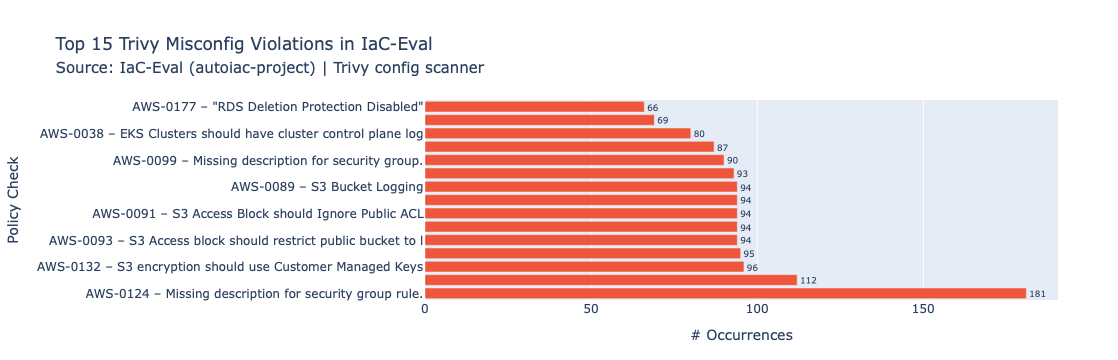

In [142]:
# ── Fig 1 · Top 15 Trivy violations ──────────────────────────────────────────
top15 = top_trivy_violations.head(15).copy()
top15['label'] = top15.apply(
    lambda r: f"{r['check_id']} – {str(r['check_title'])[:50]}", axis=1
)

fig_top = go.Figure(go.Bar(
    x=top15['count'],
    y=top15['label'],
    orientation='h',
    text=top15['count'],
    textposition='outside',
    cliponaxis=False,
    marker_color='#EF553B',
))
fig_top.update_layout(
    title="Top 15 Trivy Misconfig Violations in IaC-Eval<br>"
          "<span style='font-size:15px;font-weight:normal;'>"
          "Source: IaC-Eval (autoiac-project) | Trivy config scanner</span>",
    xaxis_title='# Occurrences',
    yaxis_title='Policy Check',
    margin=dict(l=380, r=60, t=100, b=60),
    autosize=True,
)
fig_top.write_image(str(TRIVY_OUTPUT_DIR / 'trivy_top15_violations.png'), scale=2)
fig_top.show()

top_trivy_violations.to_csv(TRIVY_OUTPUT_DIR / 'trivy_top15_violations.csv', index=False)

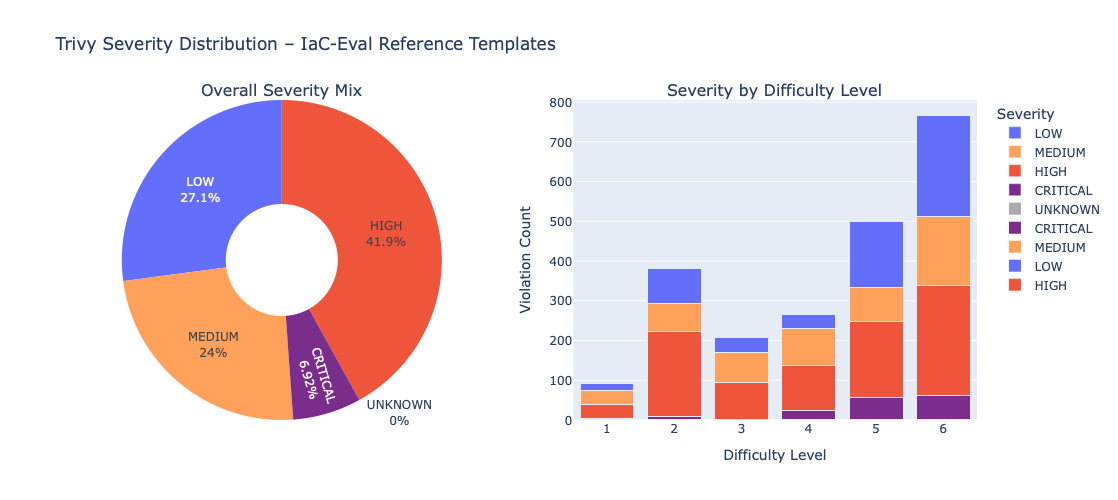

In [144]:
# ── Fig 2 · Severity breakdown ────────────────────────────────────────────────
sev_totals = {
    'CRITICAL': int(df_trivy['severity_critical'].sum()),
    'HIGH':     int(df_trivy['severity_high'].sum()),
    'MEDIUM':   int(df_trivy['severity_medium'].sum()),
    'LOW':      int(df_trivy['severity_low'].sum()),
    'UNKNOWN':  int(df_trivy['severity_unknown'].sum()),
}
sev_colors = {
    'CRITICAL': '#7B2D8B', 'HIGH': '#EF553B',
    'MEDIUM':   '#FFA15A', 'LOW':  '#636EFA', 'UNKNOWN': '#AAAAAA'
}

fig_sev = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'pie'}, {'type': 'bar'}]],
    subplot_titles=('Overall Severity Mix', 'Severity by Difficulty Level'),
)

# Pie
fig_sev.add_trace(go.Pie(
    labels=list(sev_totals.keys()),
    values=list(sev_totals.values()),
    marker_colors=[sev_colors[s] for s in sev_totals],
    hole=0.35,
    textinfo='label+percent',
), row=1, col=1)

# Stacked bar
for sev, col_name in [
    ('CRITICAL', 'total_critical'), ('HIGH', 'total_high'),
    ('MEDIUM',   'total_medium'),   ('LOW',  'total_low'),
]:
    fig_sev.add_trace(go.Bar(
        x=trivy_summary[_DIFF_COL],
        y=trivy_summary[col_name],
        name=sev,
        marker_color=sev_colors[sev],
    ), row=1, col=2)

fig_sev.update_layout(
    title='Trivy Severity Distribution – IaC-Eval Reference Templates',
    barmode='stack',
    xaxis_title='Difficulty Level',
    yaxis_title='Violation Count',
    legend_title='Severity',
    height=500,
)
fig_sev.write_image(str(TRIVY_OUTPUT_DIR / 'trivy_severity_distribution.png'), scale=2)
fig_sev.show()


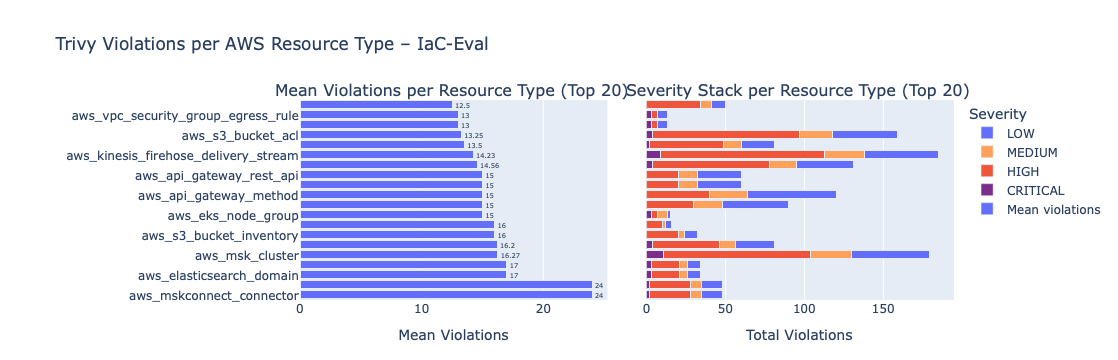

In [154]:
# ── Fig 3 · Per-resource-type analysis ───────────────────────────────────────
# Explode multi-resource scenarios (Resource col is comma-separated)
df_res_exploded = df_trivy.copy()
df_res_exploded[_RES_COL] = df_res_exploded[_RES_COL].str.split(r',\s*')
df_res_exploded = df_res_exploded.explode(_RES_COL)
df_res_exploded[_RES_COL] = df_res_exploded[_RES_COL].str.strip()

res_summary = (
    df_res_exploded.groupby(_RES_COL)
    .agg(
        scenario_count  = (_CODE_COL,             'count'),
        mean_violations = ('failed_checks',        'mean'),
        mean_swvs       = ('swvs',                 'mean'),
        pct_compliant   = ('filtered_compliance',  'mean'),
        total_critical  = ('severity_critical',    'sum'),
        total_high      = ('severity_high',        'sum'),
        total_medium    = ('severity_medium',      'sum'),
        total_low       = ('severity_low',         'sum'),
    )
    .reset_index()
    .sort_values('mean_violations', ascending=False)
)
res_summary['pct_compliant'] = (res_summary['pct_compliant'] * 100).round(1)
res_summary['mean_violations']= res_summary['mean_violations'].round(2)
res_summary['mean_swvs']      = res_summary['mean_swvs'].round(2)

# Top 20 by mean violations
top_res = res_summary.head(20)

fig_res = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        'Mean Violations per Resource Type (Top 20)',
        'Severity Stack per Resource Type (Top 20)',
    ),
    horizontal_spacing=0.06,
)

# Mean violations bar
fig_res.add_trace(go.Bar(
    x=top_res['mean_violations'],
    y=top_res[_RES_COL],
    orientation='h',
    name='Mean violations',
    marker_color='#636EFA',
    text=top_res['mean_violations'],
    textposition='outside',
    cliponaxis=False,
), row=1, col=1)

# Stacked severity bar (absolute counts)
for sev, col_name in [
    ('CRITICAL', 'total_critical'), ('HIGH', 'total_high'),
    ('MEDIUM',   'total_medium'),   ('LOW',  'total_low'),
]:
    fig_res.add_trace(go.Bar(
        x=top_res[col_name],
        y=top_res[_RES_COL],
        orientation='h',
        name=sev,
        marker_color=sev_colors[sev],
        showlegend=True,
    ), row=1, col=2)

fig_res.update_layout(
    title='Trivy Violations per AWS Resource Type – IaC-Eval',
    barmode='stack',
    height=700,
    margin=dict(l=300, r=80, t=100, b=60),
    legend_title='Severity',
)
fig_res.update_xaxes(title_text='Mean Violations', row=1, col=1)
fig_res.update_xaxes(title_text='Total Violations', row=1, col=2)
fig_res.update_yaxes(showticklabels=False, row=1, col=2)

fig_res.write_image(str(TRIVY_OUTPUT_DIR / 'trivy_per_resource_type.png'), scale=2)
fig_res.show()


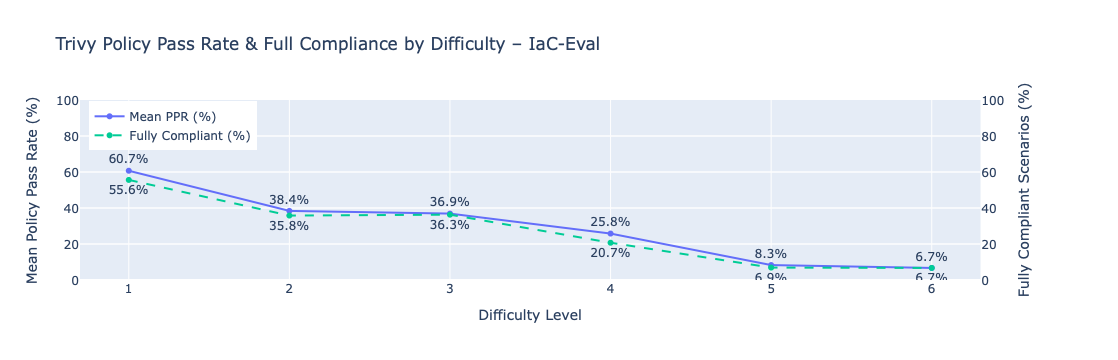

In [156]:
# ── Fig 4 · PPR & Compliance by difficulty ────────────────────────────────────
fig_ppr = make_subplots(specs=[[{'secondary_y': True}]])

fig_ppr.add_trace(go.Scatter(
    x=trivy_summary[_DIFF_COL],
    y=trivy_summary['mean_ppr'],
    mode='lines+markers+text',
    text=trivy_summary['mean_ppr'].apply(lambda v: f'{v:.1f}%'),
    textposition='top center',
    name='Mean PPR (%)',
    line=dict(color='#636EFA', width=2),
), secondary_y=False)

fig_ppr.add_trace(go.Scatter(
    x=trivy_summary[_DIFF_COL],
    y=trivy_summary['pct_compliant'],
    mode='lines+markers+text',
    text=trivy_summary['pct_compliant'].apply(lambda v: f'{v:.1f}%'),
    textposition='bottom center',
    name='Fully Compliant (%)',
    line=dict(color='#00CC96', width=2, dash='dash'),
), secondary_y=True)

fig_ppr.update_layout(
    title='Trivy Policy Pass Rate & Full Compliance by Difficulty – IaC-Eval',
    xaxis_title='Difficulty Level',
    legend=dict(x=0.01, y=0.99),
)
fig_ppr.update_yaxes(title_text='Mean Policy Pass Rate (%)', secondary_y=False, range=[0, 100])
fig_ppr.update_yaxes(title_text='Fully Compliant Scenarios (%)', secondary_y=True, range=[0, 100])

fig_ppr.write_image(str(TRIVY_OUTPUT_DIR / 'trivy_ppr_compliance_by_difficulty.png'), scale=2)
fig_ppr.show()


In [158]:
# ── IaCGen-aligned metric definitions ─────────────────────────────────────
# PPR  = mean(passed/total) over templates where total_checks > 0   (NaN excluded)
# FCR  = mean(failed==0)    over templates where total_checks > 0   (filtered)
# UCR  = mean(failed==0)    over ALL templates incl. total_checks==0 (unfiltered)

total   = len(df_trivy)
n_with_checks = (df['total_checks'] > 0).sum()

ucr = (df_trivy['failed_checks'] == 0).mean()                          # unfiltered: all 458
fcr = df_trivy.loc[df['total_checks'] > 0, 'failed_checks'].eq(0).mean()  # filtered: only those with checks
ppr = df_trivy.loc[df['total_checks'] > 0, 'policy_pass_rate'].mean()     # NaN-safe, same denominator as FCR

print(f"\nCheckov scan complete")
print(f"  Templates scanned                    : {total:,}")
print(f"  Templates with applicable checks     : {n_with_checks:,}  ({n_with_checks/total*100:.1f}%)")
print(f"  Unfiltered Compliance Rate  (UCR)    : {ucr*100:.1f}%   ← denominator: all {total}")
print(f"  Filtered   Compliance Rate  (FCR)    : {fcr*100:.1f}%   ← denominator: {n_with_checks} with checks")
print(f"  Mean Policy Pass Rate       (PPR)    : {ppr*100:.1f}%   ← denominator: {n_with_checks} with checks")
print(f"  Total violations found               : {df['failed_checks'].sum():,}")



Checkov scan complete
  Templates scanned                    : 458
  Templates with applicable checks     : 417  (91.0%)
  Unfiltered Compliance Rate  (UCR)    : 27.3%   ← denominator: all 458
  Filtered   Compliance Rate  (FCR)    : 20.4%   ← denominator: 417 with checks
  Mean Policy Pass Rate       (PPR)    : 21.8%   ← denominator: 417 with checks
  Total violations found               : 3,316
